In [ ]:
# ------------------------------------------------------------
# Notebook goal:
#   Load pre-computed SQL outputs (generated by run_query.py)
#   and use Python for light EDA + visualization + interpretation.
#
# Why this structure:
#   - SQL files in /sql contain the “source of truth” queries
#   - run_query.py executes all SQL and saves results into /outputs
#   - this notebook reads /outputs so analysis is reproducible
# ------------------------------------------------------------

# Import libraries used for analysis and file path handling
# Path().resolve() helps build file paths that work reliably on Windows.




from pathlib import Path
Path().resolve()




WindowsPath('C:/Users/palla/OneDrive/Documents/Coding Projects/Hospital Diabetes Dataset/hospital-readmissions-sql-eda/notebooks')

In [ ]:
import pandas as pd
from pathlib import Path

# Get project root
BASE_DIR = Path().resolve().parent


# Path to output file
output_path = BASE_DIR / "outputs" / "01_readmit_rate.csv"

df = pd.read_csv(output_path)

df



,readmit_30_rate_percent
0,11.16


In [ ]:
rate = df.loc[0, "readmit_30_rate_percent"]
print(f"30-day readmission rate: {rate:.2f}%")
# ------------------------------------------------------------
# Load overall readmission KPI output (from SQL):
#   01_readmit_rate.csv contains the overall 30-day readmission rate (%).
#
# This is the first “headline metric” for the dataset and mimics
# what a real analytics team would compute early in an analysis.
# ------------------------------------------------------------

30-day readmission rate: 11.16%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path().resolve().parent
age_path = BASE_DIR / "outputs" / "02_readmit_by_age.csv"

age_df = pd.read_csv(age_path)

age_df
# ------------------------------------------------------------
# Load group-level breakdown output (from SQL):
#   02_readmit_by_age.csv contains readmission rate by age group.
#
# This is classic EDA:
#   - move from a single overall KPI
#   - to segmenting the KPI across categories to find patterns
# ------------------------------------------------------------


,age,total_patients,readmit_rate_percent
0,[0-10),161,1.86
1,[10-20),691,5.79
2,[20-30),1657,14.24
3,[30-40),3775,11.23
4,[40-50),9685,10.60
5,[50-60),17256,9.67
6,[60-70),22483,11.13
7,[70-80),26068,11.77
8,[80-90),17197,12.08
9,[90-100),2793,11.10


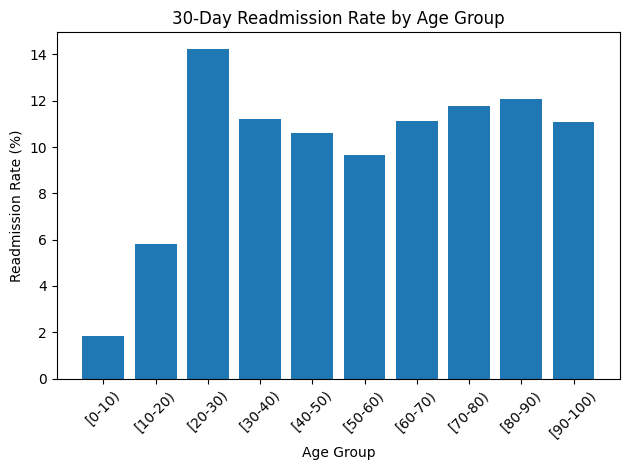

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(age_df["age"], age_df["readmit_rate_percent"])
plt.xticks(rotation=45)
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")
plt.title("30-Day Readmission Rate by Age Group")
plt.tight_layout()
plt.show()
# ------------------------------------------------------------
# Visualization:
#   Bar plot of 30-day readmission rate (%) by age group.
#
# Why visualize:
#   - A table is good for exact values
#   - A plot makes patterns and anomalies obvious at a glance
# ------------------------------------------------------------


In [ ]:
age_df.sort_values("readmit_rate_percent", ascending=False)


# ------------------------------------------------------------
# Move from aggregated outputs to patient-level data:
#   We query the SQLite database directly to get one row per encounter.
#
# We create a binary target variable:
#   readmit_binary = 1 if readmitted within 30 days ("<30")
#                 = 0 otherwise ("NO" or ">30")
#
# Why:
#   Statistical tests and predictive modeling typically need
#   patient-level data, not just aggregated tables.
# ------------------------------------------------------------


,age,total_patients,readmit_rate_percent
2,[20-30),1657,14.24
8,[80-90),17197,12.08
7,[70-80),26068,11.77
3,[30-40),3775,11.23
6,[60-70),22483,11.13
9,[90-100),2793,11.10
4,[40-50),9685,10.60
5,[50-60),17256,9.67
1,[10-20),691,5.79
0,[0-10),161,1.86


In [ ]:
# Create binary readmission column (1 = <30 days, 0 = otherwise)
import sqlite3

conn = sqlite3.connect(str(BASE_DIR.parent / "hospital_readmissions.db"))

query = """
SELECT 
    age,
    CASE WHEN readmitted = '<30' THEN 1 ELSE 0 END AS readmit_binary
FROM readmissions;
"""

binary_df = pd.read_sql(query, conn)
conn.close()

binary_df.head()

# ------------------------------------------------------------
# Statistical validation:
#   Chi-square test of independence between:
#     - age group (categorical)
#     - 30-day readmission (binary categorical)
#
# What this answers:
#   "Is readmission status associated with age group?"
#
# Why chi-square:
#   Both variables are categorical, and we want to test whether the
#   distribution of readmission differs across age groups.
#
# Output:
#   - chi2: test statistic
#   - p: p-value (very small p suggests association is unlikely due to chance)
# ------------------------------------------------------------


,age,readmit_binary
0,[0-10),0
1,[10-20),0
2,[20-30),0
3,[30-40),0
4,[40-50),0


In [ ]:
import scipy.stats as stats

# Create contingency table
contingency = pd.crosstab(binary_df["age"], binary_df["readmit_binary"])

# Run chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency)

chi2, p


# ------------------------------------------------------------
# Interpretation note:
#   With large datasets (100k+ rows), even small differences can produce
#   very small p-values. So:
#     - chi-square confirms "an association exists"
#     - it does NOT tell us the effect is large or clinically/practically important
#
# Next step (tomorrow):
#   Build a multivariable model (logistic regression) to see whether
#   age still matters after controlling for other clinical variables.
# ------------------------------------------------------------


(np.float64(116.60891071617705), np.float64(6.5979228098776415e-21))

In [2]:
import pandas as pd

df = pd.read_csv("outputs/04_cohort_readmit_rate.csv")

# Filter to one age group
age_20_30 = df[df["age"] == "[20-30)"]

pivot = age_20_30.pivot(
    index="dx_bucket",
    columns="med_bucket",
    values="readmit_30_rate_percent"
)

print(pivot)




import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(pivot, annot=True, cmap="Reds")
plt.title("Readmission Rate Heatmap: Age 20-30")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/04_cohort_readmit_rate.csv'